**Aprendizaje de Máquina Aplicado**

**Estudiantes:**
- Patricia Arango
- Santiago Higuita
- Alexander Pelaez

Repositorio del Proyecto: [Github](https://github.com/AlexanderPelaezJimenez/ml_project_eafit/tree/main)
___

**Universidad EAFIT**       
**Fecha:** 2026

---
## Tabla de Contenidos

[Under building...]

---
## Introducción y objetivos

[Under building...]


## Carga de Datos

## Import Librerías

In [1]:
from pathlib import Path

import os

import polars as pl
from loguru import logger

from sklearn.model_selection import train_test_split


import numpy as np
import pandas as pd

import optuna

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge, Lasso, LinearRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap
import joblib
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

## Carga de Datos

In [2]:
# Define random seed
SEED = 42

In [3]:
DATA_DIR = Path("../data/processed")

def load_processed_data(folder: str, format: str = "parquet"):

    logger.info(f'Cargando datos desde {folder} con formato {format}...')
    return pl.scan_parquet(f"{folder}/*.{format}").collect()

In [4]:
cleaned_dataset = load_processed_data(DATA_DIR, format="parquet")
cleaned_dataset.head(5).show()

2026-05-15 16:53:44.264 | INFO     | __main__:load_processed_data:5 - Cargando datos desde ../data/processed con formato parquet...


cole_sede_principal,cole_caracter,fami_cuartoshogar,fami_educacionpadre,estu_tipodocumento,estu_fechanacimiento,fami_tienecomputador,estu_genero,fami_tienelavadora,fami_personashogar,estu_depto_presentacion,estu_depto_reside,cole_naturaleza,cole_calendario,estu_mcpio_reside,periodo,cole_genero,fami_estratovivienda,cole_area_ubicacion,cole_bilingue,cole_mcpio_ubicacion,estu_mcpio_presentacion,fami_educacionmadre,fami_tieneautomovil,cole_jornada,punt_global,fami_tieneinternet,cole_depto_ubicacion
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""N""","""TÉCNICO/ACADÉMICO""","""Dos""","""Primaria completa""","""TI""","""15/02/2003""","""Si""","""F""","""Si""","""1 a 2""","""HUILA""","""HUILA""","""OFICIAL""","""A""","""AIPE""","""20194""","""MIXTO""","""Estrato 2""","""RURAL""","""N""","""AIPE""","""AIPE""","""Postgrado""","""No""","""COMPLETA""","""339""","""Si""","""HUILA"""
"""S""","""TÉCNICO/ACADÉMICO""","""Dos""","""Primaria incompleta""","""TI""","""08/03/2002""","""No""","""F""","""No""","""5 a 6""","""HUILA""","""HUILA""","""OFICIAL""","""A""","""LA PLATA""","""20194""","""MIXTO""","""Estrato 1""","""URBANO""","""N""","""LA PLATA""","""LA PLATA""","""Primaria incompleta""","""No""","""COMPLETA""","""199""","""No""","""HUILA"""
"""S""","""TÉCNICO/ACADÉMICO""","""Cuatro""","""Secundaria (Bachillerato) comp…","""TI""","""27/07/2000""","""Si""","""M""","""Si""","""Cinco""","""VALLE""","""VALLE""","""OFICIAL""","""A""","""CALI""","""20162""","""MIXTO""","""Estrato 5""","""URBANO""","""N""","""CALI""","""CALI""","""Secundaria (Bachillerato) inco…","""Si""","""MAÑANA""","""272""","""Si""","""VALLE"""
"""S""","""TÉCNICO/ACADÉMICO""","""Cinco""","""Primaria incompleta""","""TI""","""07/12/1999""","""No""","""F""","""Si""","""5 a 6""","""ANTIOQUIA""","""ANTIOQUIA""","""NO OFICIAL""","""A""","""MEDELLÍN""","""20172""","""MIXTO""","""Estrato 2""","""URBANO""","""N""","""MEDELLIN""","""ITAGÜÍ""","""Secundaria (Bachillerato) inco…","""No""","""SABATINA""","""253""","""Si""","""ANTIOQUIA"""
"""S""","""TÉCNICO/ACADÉMICO""","""Dos""","""Primaria incompleta""","""CC""","""15/09/1995""","""No""","""M""","""No""","""Cuatro""","""TOLIMA""","""TOLIMA""","""OFICIAL""","""A""","""SAN LUIS""","""20142""","""MIXTO""","""Estrato 1""","""RURAL""","""N""","""SAN LUIS""","""GUAMO""","""Primaria incompleta""","""No""","""MAÑANA""","""212""","""No""","""TOLIMA"""


## Split estratificado por Período

In [5]:
print(cleaned_dataset['periodo'].value_counts().sort(by='periodo').head(10))

shape: (10, 2)
┌─────────┬────────┐
│ periodo ┆ count  │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ 20142   ┆ 544535 │
│ 20151   ┆ 25947  │
│ 20152   ┆ 542450 │
│ 20161   ┆ 13064  │
│ 20162   ┆ 548206 │
│ 20171   ┆ 13018  │
│ 20172   ┆ 546261 │
│ 20181   ┆ 19798  │
│ 20191   ┆ 12540  │
│ 20194   ┆ 546211 │
└─────────┴────────┘


In [6]:
X = cleaned_dataset.drop("punt_global")
y = cleaned_dataset["punt_global"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=cleaned_dataset["periodo"]
)

print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"Proporcion test: {X_test.shape[0] / cleaned_dataset.shape[0] * 100:.1f}%")

Train: 2,716,667 filas | Test: 679,167 filas
Proporcion test: 20.0%


## Definiciones Variables

In [7]:
mapeo_personas = {
    "Uno": 1,
    "Dos": 2,
    "Tres": 3,
    "Cuatro": 4,
    "Cinco": 5,
    "Seis": 6,
    "Siete": 7,
    "Ocho": 8,
    "Nueve": 9,
    "Diez": 10,
    "Once": 11,
    "Doce o más": 12,
    "1 a 2": 1,
    "3 a 4": 3,
    "5 a 6": 5,
    "7 a 8": 7,
    "9 o más": 9
}


mapeo_cuartos = {
    "Uno": 1,
    "Dos": 2,
    "Tres": 3,
    "Cuatro": 4,
    "Cinco": 5,
    "Seis": 6,
    "Seis o mas": 6,
    "Siete": 7,
    "Ocho": 8,
    "Nueve": 9,
    "Diez o más": 10,
}

In [8]:
# Definir orden de los estratos:
orden_estrato = [
    'Sin Estrato',
    'Estrato 1',
    'Estrato 2',
    'Estrato 3',
    'Estrato 4',
    'Estrato 5',
    'Estrato 6'
]

# Definir orden de la educación:
orden_educacion = [
    'Ninguno',
    'No sabe',
    "No Aplica",
    'Primaria incompleta',
    'Primaria completa',
    'Secundaria (Bachillerato) incompleta',
    'Secundaria (Bachillerato) completa',
    'Técnica o tecnológica incompleta',
    'Técnica o tecnológica completa',
    'Educación profesional incompleta',
    'Educación profesional completa',
    'Postgrado',
]

# Clasificación de las variables:
ordinal_cols = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre'
]

binary_cols = [
    'fami_tieneinternet',
    'fami_tienecomputador',
    'fami_tieneautomovil',
    'fami_tienelavadora',
    'cole_bilingue',
    'cole_sede_principal',
    'estu_genero',
]

nominal_low_cols = [
    'cole_naturaleza',
    'cole_area_ubicacion',
    'cole_calendario',
    'cole_jornada',
    'cole_genero',
    'cole_caracter',
    'estu_tipodocumento',
    'estu_depto_reside',
    'estu_depto_presentacion',
    'cole_depto_ubicacion',
    'periodo',
]

nominal_high_cols = [
    # 'estu_mcpio_reside',
    # 'cole_mcpio_ubicacion',
    # 'estu_mcpio_presentacion',
]

numeric_cols = [
    'edad_estudiante_aprox',
    'anio_periodo',
    'fami_personashogar_num',
    'fami_cuartos_num',
    "capital_tecnologico",
    "hacinamiento",
    "max_educacion_padres",
    "indice_socioeconomico",
]

## Definición de modelos candidatos

In [9]:
from optuna import Trial, create_study, logging

logging.set_verbosity(logging.WARNING)

In [10]:
class DeterministicFeatureProcessor(BaseEstimator, TransformerMixin):
    """
    Transformer custom que aplica procesamiento determínistico.

    No aprende nada del fit (stateless), solo transforma.
    Seguro para usar dentro de un pipeline sin riesgo de leakage.
    Trabaja con pandas DataFrames (compatible con sklearn cross_val_score).
    """

    # Mapeo explicito de educacion a nivel ordinal (compartido madre/padre)
    EDUCACION_NIVEL = {
        'Ninguno': 0, 'No sabe': 0, 'No Aplica': 0,
        'Primaria incompleta': 1, 'Primaria completa': 2,
        'Secundaria (Bachillerato) incompleta': 3,
        'Secundaria (Bachillerato) completa': 4,
        'Técnica o tecnológica incompleta': 5,
        'Técnica o tecnológica completa': 6,
        'Educación profesional incompleta': 7,
        'Educación profesional completa': 8,
        'Postgrado': 9,
    }

    # Estrato a nivel numerico
    ESTRATO_NIVEL = {
        'Sin Estrato': 0,
        'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3,
        'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6,
    }

    def __init__(self, mapeo_personas: dict, mapeo_cuartos: dict, clip_edad: tuple = (15, 60)):

        self.mapeo_personas = mapeo_personas
        self.mapeo_cuartos = mapeo_cuartos
        self.clip_edad = clip_edad

    def fit(self, X, y=None):
        return self  # Stateless

    def transform(self, X):

        df = X.copy()

        # Edad aproximada (manejar nulos en fechanacimiento)
        year_periodo = df["periodo"].str[:4].astype(int)
        year_nacim = pd.to_numeric(df["estu_fechanacimiento"].str[6:10], errors="coerce")
        df["edad_estudiante_aprox"] = (year_periodo - year_nacim).clip(*self.clip_edad).astype("Int32")


        # Año del periodo como numerico (tendencia temporal)
        df["anio_periodo"] = df["periodo"].str[:4].astype(int)

        # Personas en hogar (unificar formatos)
        df["fami_personashogar_num"] = (
            df["fami_personashogar"].map(self.mapeo_personas).astype("Int32")
        )

        # Cuartos en hogar (unificar formatos)
        df["fami_cuartos_num"] = (
            df["fami_cuartoshogar"].map(self.mapeo_cuartos).astype("Int32")
        )

        # Hacinamiento: personas / cuartos (proxy de calidad de vivienda)
        df["hacinamiento"] = (
            df["fami_personashogar_num"].astype("float32") /
            df["fami_cuartos_num"].astype("float32").replace(0, np.nan)
        ).astype("float32")

        # Capital tecnologico (0/1/2)
        df["capital_tecnologico"] = (
            (df["fami_tieneinternet"] == "Si").astype(int) +
            (df["fami_tienecomputador"] == "Si").astype(int)
        )

        # Maximo nivel educativo entre madre y padre
        edu_madre = df["fami_educacionmadre"].map(self.EDUCACION_NIVEL)
        edu_padre = df["fami_educacionpadre"].map(self.EDUCACION_NIVEL)
        df["max_educacion_padres"] = (
            pd.concat([edu_madre, edu_padre], axis=1).max(axis=1).astype("Int32")
        )

        # Indice socioeconomico compuesto (suma ponderada determinista)
        # Pesos: estrato x3, capital_tecnologico x2, automovil/lavadora x1
        estrato_num = df["fami_estratovivienda"].map(self.ESTRATO_NIVEL).fillna(0).astype(int)
        auto = (df["fami_tieneautomovil"] == "Si").astype(int)
        lav = (df["fami_tienelavadora"] == "Si").astype(int)
        df["indice_socioeconomico"] = (
            3 * estrato_num + 2 * df["capital_tecnologico"] + auto + lav
        ).astype("Int32")

        # Drop columnas originales reemplazadas
        df = df.drop(columns=[
            "estu_fechanacimiento",
            "fami_personashogar",
            "fami_cuartoshogar"]
        )

        return df


class DevelopPipelineML:

    def __init__(
        self,
        preprocessor,
        mapeo_personas: dict,
        mapeo_cuartos: dict,
        clip_edad: tuple,
        n_trials_linear: int = 10,    # Ridge/Lasso
        n_trials_tree: int = 15,      # Árboles
        cv_folds: int = 4,            # Tuning inicial
        cv_folds_final: int = 5,      # Evaluación final
        parallel_trials: int = None,  # Auto-detectar si None
        cores_per_model: int = None,  # Auto-detectar si None
        random_seed: int = 42         # random seed
    ):

        # Auto-detectar capacidad de la maquina si no se especifica
        n_cpus = os.cpu_count() or 4
        if parallel_trials is None:
            # Heuristica: maximo 12 trials paralelos, o cpu/4 si la maquina es chica
            parallel_trials = max(2, min(12, n_cpus // 4))

        if cores_per_model is None:
            cores_per_model = max(1, n_cpus // parallel_trials)

        self.preprocessor = preprocessor
        self.mapeo_personas = mapeo_personas
        self.mapeo_cuartos = mapeo_cuartos
        self.clip_edad = clip_edad

        self.random_seed = random_seed
        self.n_trials_linear = n_trials_linear
        self.n_trials_tree = n_trials_tree
        self.cv_folds = cv_folds
        self.cv_folds_final = cv_folds_final
        self.parallel_trials = parallel_trials
        self.cores_per_model = cores_per_model
        self.studies = {}

        logger.info(
            f'Maquina detectada: {n_cpus} cores. '
            f'parallel_trials={parallel_trials}, cores_per_model={cores_per_model}, '
            f'concurrencia total={parallel_trials * cores_per_model}'
        )


    def build_model_grid(self, trial: Trial, model_selected: str) -> dict:

        if model_selected == "ridge":
            return {
                "model_type": "linear",
                "params_grid": {
                    "alpha": trial.suggest_float("alpha", 1e-3, 1000.0, log=True),
                },
            }

        elif model_selected == "lasso":
            return {
                "model_type": "linear",
                "params_grid": {
                    "alpha": trial.suggest_float("alpha", 1, 500.0, log=True),
                    "max_iter": 2000,
                },
            }

        elif model_selected == "randomForest":
            return {
                "model_type": "tree",
                "params_grid": {
                    "n_estimators": trial.suggest_int("n_estimators", 100, 500),
                    "max_depth": trial.suggest_int("max_depth", 6, 20),
                    "min_samples_split": trial.suggest_int("min_samples_split", 5, 50),
                    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 30),
                    "max_features": trial.suggest_float("max_features", 0.3, 1.0),
                },
            }

        elif model_selected == "lightGBM":
            return {
                "model_type": "tree",
                "params_grid": {
                    "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
                    "max_depth": trial.suggest_int("max_depth", 4, 12),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                    "num_leaves": trial.suggest_int("num_leaves", 20, 150),
                    "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
                    "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                    "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                    "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
                },
            }

        elif model_selected == "xgboost":
            return {
                "model_type": "tree",
                "params_grid": {
                    "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
                    "max_depth": trial.suggest_int("max_depth", 4, 12),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                    "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                    "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                    "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
                    "min_child_weight": trial.suggest_int("min_child_weight", 1, 50),
                    "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
                },
            }

        elif model_selected == "catboost":
            return {
                "model_type": "tree",
                "params_grid": {
                    "iterations": trial.suggest_int("iterations", 200, 1000),
                    "depth": trial.suggest_int("depth", 4, 10),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                    "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
                    "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
                    "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
                },
            }

        return {}


    def build_pipeline(self, model_selected: str, params: dict, model_type: str) -> Pipeline:

        deterministic = DeterministicFeatureProcessor(
            self.mapeo_personas,
            self.mapeo_cuartos,
            self.clip_edad
        )

        if model_type == 'linear':

            model = Ridge(**params) if model_selected == 'ridge' else Lasso(**params)

            full_pipeline = Pipeline([
                ("deterministic", deterministic),
                ("preprocessor", self.preprocessor),
                ("scaler", StandardScaler()),
                ("model", model),
            ])

        elif model_type == 'tree':

            if model_selected == 'randomForest':
                model = RandomForestRegressor(
                    **params,
                    random_state=self.random_seed,
                    n_jobs=self.cores_per_model
                )

            elif model_selected == 'lightGBM':
                model = LGBMRegressor(
                    **params,
                    random_state=self.random_seed,
                    verbose=-1,
                    n_jobs=self.cores_per_model
                )

            elif model_selected == 'xgboost':
                model = XGBRegressor(
                    **params, 
                    random_state=self.random_seed,
                    verbosity=0,
                    tree_method="hist",
                    nthread=self.cores_per_model
                )

            else:
                model = CatBoostRegressor(
                    **params,
                    random_state=self.random_seed,
                    verbose=0,
                    thread_count=self.cores_per_model
                )

            full_pipeline = Pipeline([
                ("deterministic", deterministic),
                ("preprocessor", self.preprocessor),
                ("model", model),
            ])

        return full_pipeline


    def objective_model(self, trial, model_selected: str, random_seed: int):

        config = self.build_model_grid(trial, model_selected)
        params = config.get("params_grid", {})
        model_type = config.get("model_type", None)

        assert params, f"Modelo {model_selected} sin parámetros en la configuración."
        assert model_type is not None, f"Modelo {model_selected} no encontrado en la configuración."


        full_pipeline = self.build_pipeline(
            model_selected=model_selected,
            params=params,
            model_type=model_type
        )

        scores = cross_val_score(
            full_pipeline,
            self.X_train,
            self.y_train,
            cv=self.cv_folds,
            scoring="neg_root_mean_squared_error",
            n_jobs=self.cv_folds  # paraleliza los folds
        )

        return -scores.mean()


    def tune(self, X_train, y_train, models: list):

        self.X_train = X_train
        self.y_train = y_train

        for model_name in models:
            logger.info(f'Ejecutando modelo {model_name}...')

            # Trials y paralelismo según tipo de modelo
            is_linear = model_name in ['ridge', 'lasso']
            n_trials = self.n_trials_linear if is_linear else self.n_trials_tree
            n_jobs_optuna = self.parallel_trials  # paralelizar siempre, lineales y arboles

            study = create_study(direction="minimize", study_name=f'Experimento usando: {model_name}')
            study.optimize(
                lambda trial, m=model_name, r=self.random_seed: self.objective_model(trial, model_selected=m, random_seed=r),
                n_trials=n_trials,
                n_jobs=n_jobs_optuna,
                show_progress_bar=True
            )

            self.studies[model_name] = study

            logger.info(f'{model_name} | Mejor RMSE CV: {study.best_value:.4f}')
            logger.info(f'{model_name} | Mejores params: {study.best_params}')

        return self.studies


    def fit_best(self, model_name: str, X_train, y_train) -> Pipeline:
        """
        Reentrena el modelo seleccionado con los mejores hiperparametros
        encontrados en tune(), usando todo el train.

        NO toca el test holdout. El reentrenamiento final no introduce leakage.
        """
        if model_name not in self.studies:
            raise ValueError(f"Modelo '{model_name}' no tiene estudio. Corre tune() primero.")

        study = self.studies[model_name]
        best_params = dict(study.best_params)

        is_linear = model_name in ['ridge', 'lasso']
        model_type = 'linear' if is_linear else 'tree'

        # Re-inyectar params fijos no optimizados
        if model_name == 'lasso':
            best_params['max_iter'] = 2000

        logger.info(f'Reentrenando {model_name} con todo el train ({len(X_train):,} filas)...')
        self.best_pipeline = self.build_pipeline(
            model_selected=model_name,
            params=best_params,
            model_type=model_type,
        )
        self.best_pipeline.fit(X_train, y_train)
        self.best_model_name = model_name

        logger.info(f'{model_name} entrenado y disponible en self.best_pipeline')
        return self.best_pipeline


    def evaluate(self, X_test, y_test) -> dict:
        """
        Evalua el pipeline campeon en el test holdout.
        Solo se debe llamar UNA vez al final del proyecto.
        """
        if not hasattr(self, 'best_pipeline'):
            raise ValueError('No hay modelo campeon. Corre fit_best() primero.')

        predictions = self.best_pipeline.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        report = {
            'model': self.best_model_name,
            'rmse': float(rmse),
            'mae': float(mae),
            'r2': float(r2),
            'n_test': len(y_test),
        }

        logger.info(f'Test holdout: {report}')
        return report


    def comparison_table(self) -> pd.DataFrame:
        """
        Tabla comparativa de los modelos del tuning, ordenada por RMSE de CV.
        """
        if not self.studies:
            raise ValueError('No hay estudios. Corre tune() primero.')

        rows = [
            {
                'model': name,
                'best_cv_rmse': study.best_value,
                'n_trials': len(study.trials),
                'best_params': study.best_params,
            }
            for name, study in self.studies.items()
        ]

        return (
            pd.DataFrame(rows)
            .sort_values('best_cv_rmse')
            .reset_index(drop=True)
        )


    def explain(self, X_train, sample_size: int = 50_000) -> pd.DataFrame:
        """
        Calcula SHAP values del modelo campeon sobre una muestra de train.

        Importante: SHAP se calcula sobre TRAIN, nunca sobre test.
        Usar SHAP de test para feature selection seria leakage.
        """
        if not hasattr(self, 'best_pipeline'):
            raise ValueError('No hay modelo campeon. Corre fit_best() primero.')

        rng = np.random.RandomState(self.random_seed)
        n = len(X_train)
        idx = rng.choice(n, min(sample_size, n), replace=False)
        X_sample = X_train.iloc[idx] if hasattr(X_train, 'iloc') else X_train[idx]

        deterministic = self.best_pipeline.named_steps['deterministic']
        preproc = self.best_pipeline.named_steps['preprocessor']
        model = self.best_pipeline.named_steps['model']

        X_det = deterministic.transform(X_sample)
        X_transformed = preproc.transform(X_det)
        feature_names = preproc.get_feature_names_out()

        logger.info(f'Calculando SHAP values sobre {len(X_sample):,} muestras...')
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_transformed)

        self._shap_values = shap_values
        self._shap_X = X_transformed
        self._shap_feature_names = list(feature_names)

        importance_df = pd.DataFrame({
            'feature': feature_names,
            'mean_abs_shap': np.abs(shap_values).mean(axis=0),
        }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

        return importance_df


    def plot_shap_summary(self, max_display: int = 20, save_path: str = None):
        """Summary plot (beeswarm). Requiere haber corrido explain()."""
        if not hasattr(self, '_shap_values'):
            raise ValueError('Se debe correr explain() primero.')

        shap.summary_plot(
            self._shap_values, self._shap_X,
            feature_names=self._shap_feature_names,
            max_display=max_display, show=False,
        )

        if save_path:
            plt.tight_layout()
            plt.savefig(save_path, dpi=120, bbox_inches='tight')

        plt.show()


    def plot_shap_importance(self, max_display: int = 20, save_path: str = None):
        """Bar plot de importancia absoluta promedio."""
        if not hasattr(self, '_shap_values'):
            raise ValueError('Se debe correr explain() primero.')

        shap.summary_plot(
            self._shap_values, self._shap_X,
            feature_names=self._shap_feature_names,
            plot_type='bar', max_display=max_display, show=False,
        )

        if save_path:
            plt.tight_layout()
            plt.savefig(save_path, dpi=120, bbox_inches='tight')

        plt.show()


    def plot_shap_dependence(self, feature: str, save_path: str = None):
        """Dependence plot para una feature especifica."""
        if not hasattr(self, '_shap_values'):
            raise ValueError('Corre explain() primero.')

        if feature not in self._shap_feature_names:
            raise ValueError(f"Feature '{feature}' no encontrada en el pipeline transformado.")

        feature_idx = self._shap_feature_names.index(feature)
        shap.dependence_plot(
            feature_idx, self._shap_values, self._shap_X,
            feature_names=self._shap_feature_names, show=False,
        )

        if save_path:
            plt.tight_layout()
            plt.savefig(save_path, dpi=120, bbox_inches='tight')

        plt.show()


    def save(self, path: str):
        """Serializa el pipeline campeon con joblib."""
        if not hasattr(self, 'best_pipeline'):
            raise ValueError('No hay modelo campeon. Se debe correr fit_best() primero.')

        joblib.dump(self.best_pipeline, path)
        logger.info(f'Pipeline guardado en {path}')


    @staticmethod
    def load(path: str) -> Pipeline:
        """Carga un pipeline serializado."""
        pipeline = joblib.load(path)

        logger.info(f'Pipeline cargado desde {path}')
        return pipeline

## Hyperparameter tuning con Optuna

In [11]:
preprocessor = ColumnTransformer([
    ("ordinal", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            categories=[orden_estrato, orden_educacion, orden_educacion],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )),
    ]), ordinal_cols),

    ("binary", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), binary_cols),

    ("nominal_low", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), nominal_low_cols),

    ("nominal_high", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), nominal_high_cols),

    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), numeric_cols),
], remainder="drop")

In [12]:
dev_pipeline_ml = DevelopPipelineML(
    preprocessor=preprocessor,
    mapeo_personas=mapeo_personas,
    mapeo_cuartos=mapeo_cuartos,
    clip_edad=(15, 60),
    n_trials_linear=15,
    n_trials_tree=25,
    cv_folds=4,
    parallel_trials=4,           # 4 trials en paralelo
    cores_per_model=4,           # 4 cores para el modelo
)

2026-05-15 16:53:52.992 | INFO     | __main__:__init__:140 - Maquina detectada: 72 cores. parallel_trials=4, cores_per_model=4, concurrencia total=16


In [13]:
models_to_tune = [
    'ridge',
    'lasso',
    'randomForest',
    'lightGBM',
    'xgboost',
    'catboost'
]

X_train_pd = X_train.to_pandas()
y_train_np = y_train.cast(pl.Int32).to_numpy().astype(np.float32)

# Primero: lineales + boosters
studies = dev_pipeline_ml.tune(
    X_train_pd, y_train_np,
    models=['ridge', 'lasso', 'lightGBM', 'xgboost', 'catboost']
)

# Después: RF con menos trials
dev_pipeline_ml.n_trials_tree = 10
studies = dev_pipeline_ml.tune(
    X_train_pd, y_train_np,
    models=['randomForest']
)


# 2. Tabla comparativa
display(dev_pipeline_ml.comparison_table())

2026-05-15 16:54:04.244 | INFO     | __main__:tune:322 - Ejecutando modelo ridge...


  0%|          | 0/15 [00:00<?, ?it/s]

2026-05-15 17:04:27.475 | INFO     | __main__:tune:339 - ridge | Mejor RMSE CV: 39.9752
2026-05-15 17:04:27.476 | INFO     | __main__:tune:340 - ridge | Mejores params: {'alpha': 226.47422069913029}
2026-05-15 17:04:27.476 | INFO     | __main__:tune:322 - Ejecutando modelo lasso...


  0%|          | 0/15 [00:00<?, ?it/s]

2026-05-15 17:16:36.982 | INFO     | __main__:tune:339 - lasso | Mejor RMSE CV: 40.4681
2026-05-15 17:16:36.983 | INFO     | __main__:tune:340 - lasso | Mejores params: {'alpha': 1.0156214127799161}
2026-05-15 17:16:36.984 | INFO     | __main__:tune:322 - Ejecutando modelo lightGBM...


...

2026-05-15 18:46:22.798 | INFO     | __main__:tune:339 - xgboost | Mejor RMSE CV: 37.4866
2026-05-15 18:46:22.799 | INFO     | __main__:tune:340 - xgboost | Mejores params: {'n_estimators': 269, 'max_depth': 12, 'learning_rate': 0.09852804583349671, 'subsample': 0.8564708502557421, 'colsample_bytree': 0.7566830580230414, 'reg_alpha': 0.004873161741572912, 'reg_lambda': 7.033299033536655, 'min_child_weight': 17, 'gamma': 1.4140613096134783e-08}
2026-05-15 18:46:22.800 | INFO     | __main__:tune:322 - Ejecutando modelo catboost...


  0%|          | 0/25 [00:00<?, ?it/s]

2026-05-15 19:36:47.958 | INFO     | __main__:tune:339 - catboost | Mejor RMSE CV: 37.4311
2026-05-15 19:36:47.960 | INFO     | __main__:tune:340 - catboost | Mejores params: {'iterations': 860, 'depth': 9, 'learning_rate': 0.18219789440690995, 'l2_leaf_reg': 0.007987527018018943, 'bagging_temperature': 0.9973301937473056, 'random_strength': 0.00464583057592724}
2026-05-15 19:36:47.960 | INFO     | __main__:tune:322 - Ejecutando modelo randomForest...


  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [15]:
X_test_pd = X_test.to_pandas()
y_test_np = y_test.cast(pl.Int32).to_numpy().astype(np.float32)

# 3. Best Model (Se debe reemplazar el champion por el modelo ganador de la tabla comparativa)
dev_pipeline_ml.fit_best("catboost", X_train_pd, y_train_np)

# 4. Evaluar en test
test_metrics = dev_pipeline_ml.evaluate(X_test_pd, y_test_np)

2026-05-15 19:40:06.586 | INFO     | __main__:fit_best:365 - Reentrenando catboost con todo el train (2,716,667 filas)...
2026-05-15 19:43:35.317 | INFO     | __main__:fit_best:374 - catboost entrenado y disponible en self.best_pipeline
2026-05-15 19:43:41.459 | INFO     | __main__:evaluate:399 - Test holdout: {'model': 'catboost', 'rmse': 37.38336633647347, 'mae': 29.805848547614477, 'r2': 0.4370104189321766, 'n_test': 679167}


In [16]:
# 5. SHAP sobre TRAIN
importance_df = dev_pipeline_ml.explain(X_train_pd, sample_size=50_000)
display(importance_df.head(20))

2026-05-15 19:44:20.283 | INFO     | __main__:explain:450 - Calculando SHAP values sobre 50,000 muestras...
/opt/conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,feature,mean_abs_shap
0,numeric__edad_estudiante_aprox,7.852740
1,numeric__max_educacion_padres,4.421365
2,binary__estu_genero,4.146274
3,numeric__capital_tecnologico,3.783163
4,nominal_low__cole_jornada_COMPLETA,3.233407
5,ordinal__fami_estratovivienda,2.857983
6,nominal_low__cole_jornada_SABATINA,2.827146
7,numeric__anio_periodo,2.725142
8,nominal_low__cole_jornada_NOCHE,2.548787
9,ordinal__fami_educacionpadre,2.279572


/opt/conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


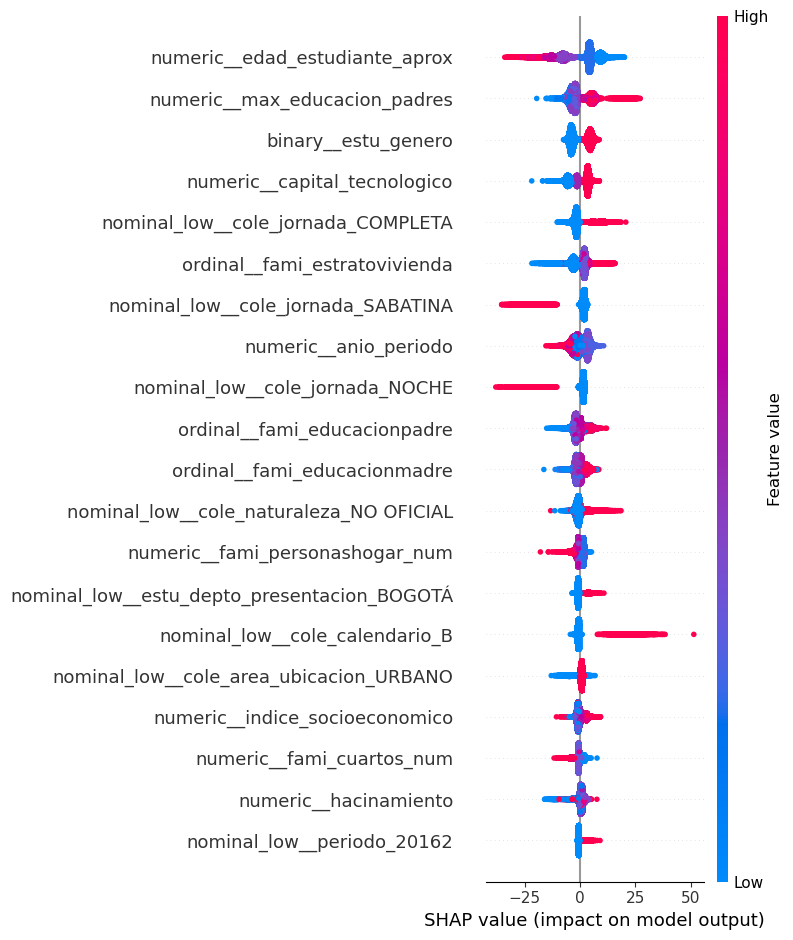

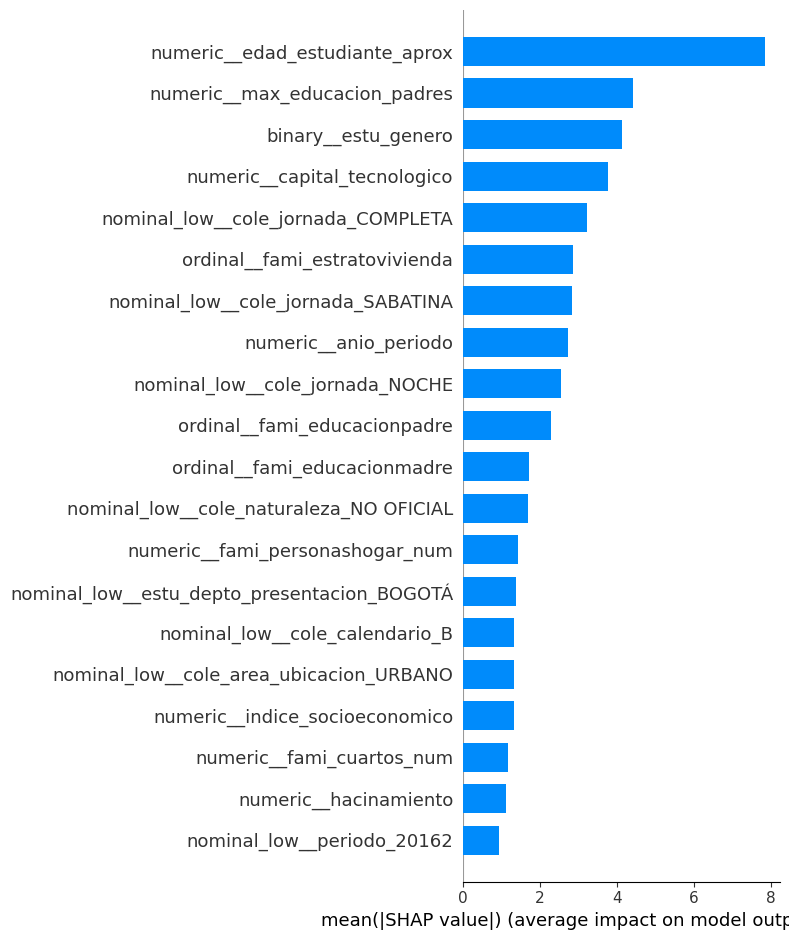

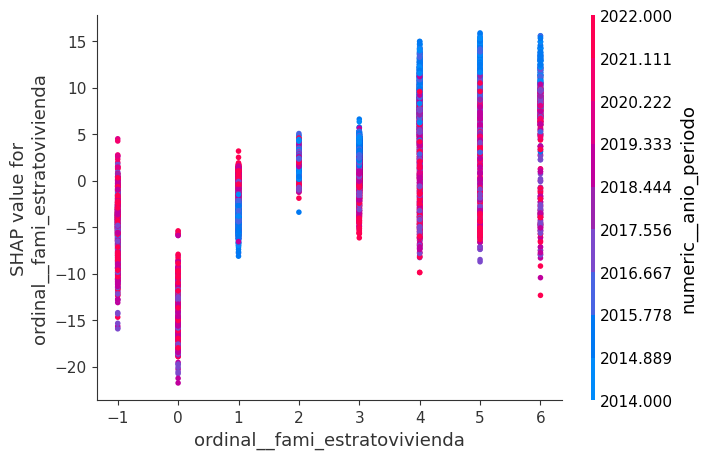

2026-05-15 19:46:35.841 | INFO     | __main__:save:529 - Pipeline guardado en ../models/best_pipeline.joblib


In [19]:
# 6. Plots
dev_pipeline_ml.plot_shap_summary(save_path="../reports/figures/shap_summary.png")
dev_pipeline_ml.plot_shap_importance(save_path="../reports/figures/shap_importance.png")
dev_pipeline_ml.plot_shap_dependence("ordinal__fami_estratovivienda")

# 7. Guardar campeón
dev_pipeline_ml.save("../models/best_pipeline.joblib")

---
## Resultados y comparación de modelos

[Under building...]


## Conclusión Etapa

[Under building...]

### Conclusión interim

[Under building...]

In [14]:
X_train_pd = X_train.to_pandas()
y_train_np = y_train.cast(pl.Int32).to_numpy().astype(np.float32)

In [15]:
import time
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Asumo que ya tienes preprocessor, X_train_pd, y_train_np listos
# y DeterministicFeatureProcessor

det = DeterministicFeatureProcessor(mapeo_personas, mapeo_cuartos, (15, 60))

# Test 1: deterministic solo
t = time.time()
X_det = det.transform(X_train_pd)
print(f"[1] Deterministic en 2.7M filas: {time.time()-t:.2f}s")

# Test 2: preprocessor solo, sobre el output del deterministic
t = time.time()
X_t = preprocessor.fit_transform(X_det)
print(f"[2] Preprocessor en 2.7M filas: {time.time()-t:.2f}s")
print(f"    Shape resultante: {X_t.shape}")

# Test 3: Ridge solo, sobre datos ya transformados
t = time.time()
ridge = Ridge(alpha=1.0)
ridge.fit(X_t, y_train_np)
print(f"[3] Ridge.fit sobre 2.7M filas transformadas: {time.time()-t:.2f}s")

# Test 4: pipeline completo (1 sola pasada, sin CV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("deterministic", DeterministicFeatureProcessor(mapeo_personas, mapeo_cuartos, (15, 60))),
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

t = time.time()
pipe.fit(X_train_pd, y_train_np)
print(f"[4] Pipeline completo (fit 1 vez): {time.time()-t:.2f}s")

# Test 5: cross_val_score con 1 trial, n_jobs=1
t = time.time()
scores = cross_val_score(pipe, X_train_pd, y_train_np, cv=3, scoring="neg_root_mean_squared_error", n_jobs=1)
print(f"[5] CV=3 secuencial: {time.time()-t:.2f}s")

# Test 6: cross_val_score con n_jobs=3 (paralelizar folds)
t = time.time()
scores = cross_val_score(pipe, X_train_pd, y_train_np, cv=3, scoring="neg_root_mean_squared_error", n_jobs=3)
print(f"[6] CV=3 paralelo: {time.time()-t:.2f}s")

[1] Deterministic en 2.7M filas: 7.30s
[2] Preprocessor en 2.7M filas: 23.20s
    Shape resultante: (2716667, 180)
[3] Ridge.fit sobre 2.7M filas transformadas: 5.65s
[4] Pipeline completo (fit 1 vez): 42.78s
[5] CV=3 secuencial: 111.03s
[6] CV=3 paralelo: 50.37s
